# Model benchmarks: MMLU vs HLE

Benchmark figures for the (non-embedding) chat/reasoning models declared in `models.just`.

- **MMLU** — Massive Multitask Language Understanding (% accuracy). Most 2026 reporting uses **MMLU-Pro**, the harder variant; where only standard MMLU was available it is flagged in `mmlu_kind`.
- **HLE** — *Humanity's Last Exam* (% accuracy), a frontier reasoning benchmark.

Values were collected from public model cards, vendor posts and aggregators (Artificial Analysis, llm-stats, Hugging Face, vendor blogs). They mix evaluation harnesses / shot-counts and should be treated as **indicative, not strictly comparable**. Models with no reliable published number are left as `NaN`.

> Note: an earlier search returned an implausible HLE of 85.4% for *MiniMax-M3*; it has been replaced with the Artificial Analysis figure of **37%**. Some HLE figures are reported *with tool use* (flagged in `note`), which inflates them relative to no-tools runs.

Embedding / ASR models (`qwen3-embedding-*`, `e5-*`, `text-embedding-ada-002`, `faster-whisper-*`, etc.) are excluded — they don't have MMLU/HLE.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# directory where plots are saved as PNGs
FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

# model: (mmlu_pro, mmlu_std, hle, note)
# mmlu_pro / mmlu_std in %, hle in %. NaN where no reliable public figure.
rows = [
    # model                         mmlu_pro  mmlu_std   hle    note
    ("GLM-4.7",                       84.6,    np.nan,  42.8,  "HLE w/ tools"),
    ("gpt-oss-120b",                np.nan,      90.0,  18.5,  ""),
    ("MiniMax-M2",                    82.0,    np.nan,  12.5,  ""),
    ("MiniMax-M3",                  np.nan,    np.nan,  37.0,  "HLE via Artificial Analysis"),
    ("Qwen3.5-122B-A10B",            86.1,    np.nan,  25.3,  "HLE w/ CoT"),
    ("Qwen3.5-397B-A17B",            87.8,    np.nan,  48.3,  "HLE w/ tools"),
    ("Qwen3.6-35B-A3B",              85.2,    np.nan,  21.4,  ""),
    ("Qwen3-30B-A3B-Instruct-2507",  74.2,     87.1,  np.nan, ""),
    ("Qwen3-Coder-30B-A3B",        np.nan,      87.0,  np.nan, "shared Qwen3-30B base"),
    ("Mistral-Large-3-675B",         80.7,    np.nan,  np.nan, ""),
    ("Mistral-Small-3.1-24B",      np.nan,      80.6,  np.nan, ""),
    ("DeepSeek-R1-Distill-Llama-70B",71.2,    np.nan,  np.nan, ""),
    ("Gemma-4-31B",                  85.2,    np.nan,  26.5,  "HLE 22.7-26.5 across sources"),
    ("MedGemma-27B",               np.nan,      67.0,  np.nan, "medical MMLU"),
    ("Llama-3.1-8B-Instruct",      np.nan,      69.4,  np.nan, "5-shot"),
    ("Apertus-8B-Instruct",          31.1,     62.8,  np.nan, ""),
    ("Apertus-70B-Instruct",       np.nan,    np.nan,  np.nan, "AAII=8, no MMLU"),
    ("Teuken-7B",                  np.nan,    np.nan,  np.nan, "EU-leaderboard only"),
    ("InternVL3.5-30B-A3B",        np.nan,    np.nan,  np.nan, "multimodal"),
    ("Devstral-2-123B",            np.nan,    np.nan,  np.nan, "coding (SWE-bench)"),
    ("Qwen3-Coder-Next",           np.nan,    np.nan,  np.nan, "coding"),
]

df = pd.DataFrame(rows, columns=["model", "mmlu_pro", "mmlu_std", "hle", "note"])

# SWE-bench Verified (% resolved). NaN where no reliable public figure.
# Scores vary with agent scaffold / shot-count; rough comparison only.
swe = {
    "GLM-4.7": 74.2,                  # 59-74 across sources; agentic-scaffold value used
    "gpt-oss-120b": 62.0,
    "MiniMax-M3": 80.5,
    "Qwen3.5-122B-A10B": 72.4,
    "Qwen3.5-397B-A17B": 76.2,
    "Qwen3.6-35B-A3B": 73.4,
    "Qwen3-Coder-30B-A3B": 50.0,      # Pass@1
    "Qwen3-Coder-Next": 70.6,
    "Devstral-2-123B": 72.2,
}
df["swe"] = df["model"].map(swe)

# unified MMLU column: prefer MMLU-Pro, fall back to standard MMLU
df["mmlu"] = df["mmlu_pro"].fillna(df["mmlu_std"])
df["mmlu_kind"] = np.where(df["mmlu_pro"].notna(), "MMLU-Pro",
                   np.where(df["mmlu_std"].notna(), "MMLU", ""))
df

,model,mmlu_pro,mmlu_std,hle,note,swe,mmlu,mmlu_kind
0,GLM-4.7,84.6,NaN,42.8,HLE w/ tools,74.2,84.6,MMLU-Pro
1,gpt-oss-120b,NaN,90.0,18.5,,62.0,90.0,MMLU
2,MiniMax-M2,82.0,NaN,12.5,,NaN,82.0,MMLU-Pro
3,MiniMax-M3,NaN,NaN,37.0,HLE via Artificial Analysis,80.5,NaN,
4,Qwen3.5-122B-A10B,86.1,NaN,25.3,HLE w/ CoT,72.4,86.1,MMLU-Pro
5,Qwen3.5-397B-A17B,87.8,NaN,48.3,HLE w/ tools,76.2,87.8,MMLU-Pro
6,Qwen3.6-35B-A3B,85.2,NaN,21.4,,73.4,85.2,MMLU-Pro
7,Qwen3-30B-A3B-Instruct-2507,74.2,87.1,NaN,,NaN,74.2,MMLU-Pro
8,Qwen3-Coder-30B-A3B,NaN,87.0,NaN,shared Qwen3-30B base,50.0,87.0,MMLU
9,Mistral-Large-3-675B,80.7,NaN,NaN,,NaN,80.7,MMLU-Pro


## MMLU per model

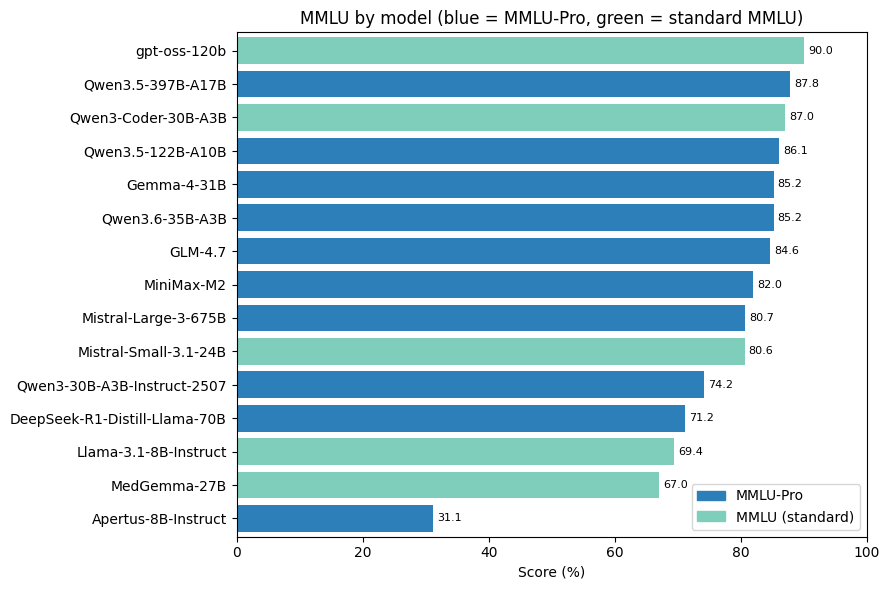

In [2]:
d = df.dropna(subset=["mmlu"]).sort_values("mmlu", ascending=True)
colors = np.where(d["mmlu_kind"].values == "MMLU-Pro", "#2c7fb8", "#7fcdbb")

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(d["model"], d["mmlu"], color=colors)
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
ax.set_xlabel("Score (%)")
ax.set_title("MMLU by model (blue = MMLU-Pro, green = standard MMLU)")
ax.set_xlim(0, 100)
ax.margins(y=0.01)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2c7fb8", label="MMLU-Pro"),
                   Patch(color="#7fcdbb", label="MMLU (standard)")], loc="lower right")
plt.tight_layout()
fig.savefig(FIGDIR / "mmlu_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

## HLE (Humanity's Last Exam) per model

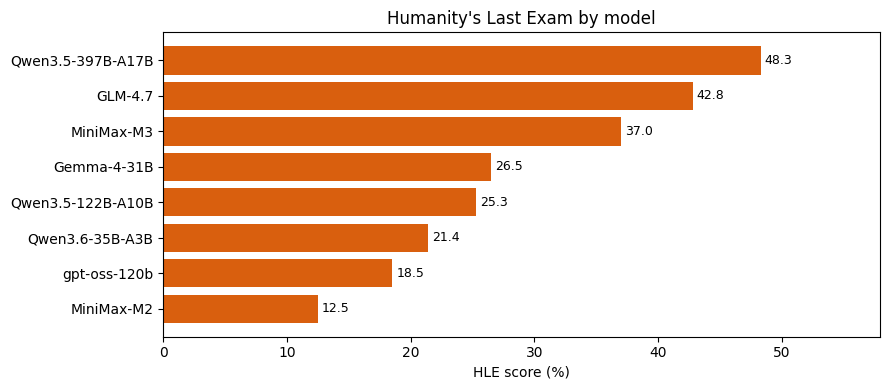

In [3]:
h = df.dropna(subset=["hle"]).sort_values("hle", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(h["model"], h["hle"], color="#d95f0e")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
ax.set_xlabel("HLE score (%)")
ax.set_title("Humanity's Last Exam by model")
ax.set_xlim(0, max(h["hle"]) * 1.2)
plt.tight_layout()
fig.savefig(FIGDIR / "hle_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

## SWE-bench Verified per model

Coding benchmark (% of real GitHub issues resolved). Figures vary with the agent scaffold (SWE-agent / OpenHands / mini-SWE-agent) and Pass@k, so treat as indicative.

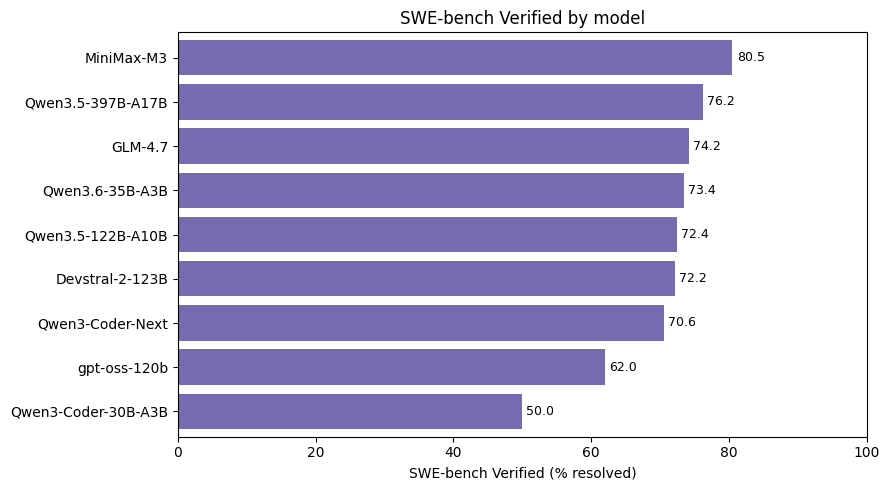

In [4]:
s = df.dropna(subset=["swe"]).sort_values("swe", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(s["model"], s["swe"], color="#756bb1")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
ax.set_xlabel("SWE-bench Verified (% resolved)")
ax.set_title("SWE-bench Verified by model")
ax.set_xlim(0, 100)
ax.margins(y=0.02)
plt.tight_layout()
fig.savefig(FIGDIR / "swe_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

## MMLU vs HLE relationship

Only models with both metrics published. MMLU here is MMLU-Pro except where annotated (`gpt-oss-120b` uses standard MMLU).

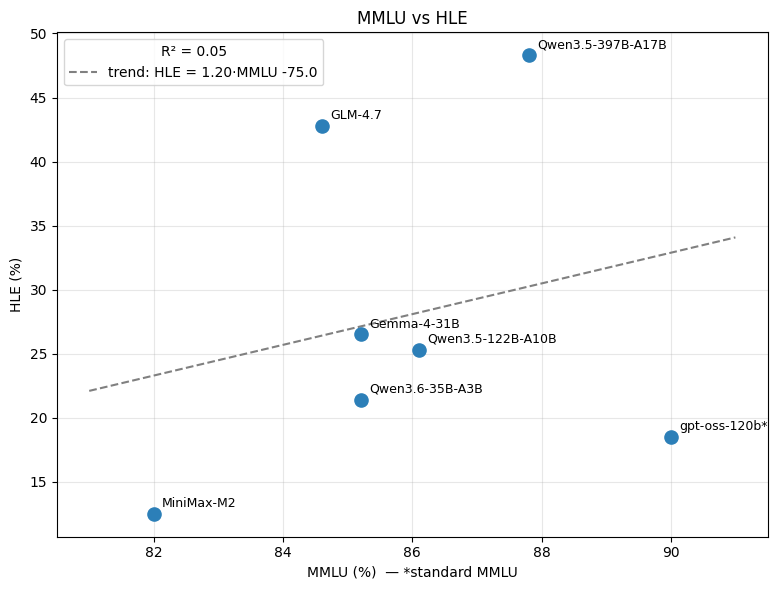

In [5]:
rel = df.dropna(subset=["mmlu", "hle"]).copy()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(rel["mmlu"], rel["hle"], s=90, color="#2c7fb8", zorder=3)
for _, r in rel.iterrows():
    label = r["model"] + ("*" if r["mmlu_kind"] != "MMLU-Pro" else "")
    ax.annotate(label, (r["mmlu"], r["hle"]), textcoords="offset points",
                xytext=(6, 5), fontsize=9)

# linear trend
if len(rel) >= 2:
    m, b = np.polyfit(rel["mmlu"], rel["hle"], 1)
    xs = np.linspace(rel["mmlu"].min() - 1, rel["mmlu"].max() + 1, 50)
    ax.plot(xs, m * xs + b, "--", color="grey", zorder=2,
            label=f"trend: HLE = {m:.2f}·MMLU {b:+.1f}")
    r2 = np.corrcoef(rel["mmlu"], rel["hle"])[0, 1] ** 2
    ax.legend(title=f"R² = {r2:.2f}", loc="upper left")

ax.set_xlabel("MMLU (%)  — *standard MMLU")
ax.set_ylabel("HLE (%)")
ax.set_title("MMLU vs HLE")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGDIR / "mmlu_vs_hle.png", dpi=150, bbox_inches="tight")
plt.show()

### Sources (indicative)

Artificial Analysis (HLE leaderboard & per-model pages), llm-stats.com, Hugging Face model cards, and vendor blogs/posts for: GLM-4.7, gpt-oss-120b, MiniMax-M2, Qwen3.5-122B/397B, Qwen3.6-35B, Qwen3-30B-A3B-2507, Mistral-Large-3 / Mistral-Small-3.1, DeepSeek-R1-Distill-Llama-70B, Gemma-4-31B, MedGemma-27B, Llama-3.1-8B, Apertus-8B/70B, Teuken-7B, InternVL3.5-30B, Devstral-2.

Figures combine differing harnesses/shot-counts and are for rough comparison only.